# 2T Optimal Filter

The following code takes four arrays:
1. "fast" / "residual" template ($s_{R}(t)$)
2. "slow" / "phonon" template ($s_{P}(t)$)
3. pulse ($v(t)$)
4. noise sample (PSD) ($n(f)$)

and performs an optimization on two free parameters:
1. "fast" template amplitude ($\hat{A}_{R}$)
2. "slow" template amplitude ($\hat{A}_{P}$)
3. overall time-shift ($\hat{t}$)

Express the reconstructed pulse in frequency space as $\tilde{v}(f) = \hat{A}_{R} \cdot \tilde{s}_{R}(f) + \hat{A}_{P} \cdot \tilde{s}_{P}(f) + n(f)$


For more information, please see the [SuperCDMS Processing Documentation](https://supercdms.gitlab.io/Reconstruction/cdmsbats/BatCommon/OF/)

In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
from scipy.fft import fft, fftfreq
from scipy.optimize import minimize
import os,sys

CDMS = os.environ["CDMS"] # set in ~/.bash_profile
SuperSim = "/scratch/group/mitchcomp/eb/x86_64/sw/supersim/V14-02-01-foss-2022b"
stylesheet = os.path.join(CDMS,"scripts","stylesheets","steel_reduced.mplstyle")
plt.style.use(stylesheet)

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
import setup
import detectorLayout

In [3]:
SuperSim = os.environ["CDMS_SUPERSIM"]
fastTemplateFile = os.path.join(SuperSim,"CDMSgeometry","data","dmc","CDMSlite1","TESTemplatesFast")
fastTemplateData = pd.read_csv(fastTemplateFile,sep="\t")

## Setup

In [3]:
DMCfiles = ("/scratch/group/mitchcomp/CDMS/data/nolan/Lei_Samples/CDMSlite_EPot/samples/hits/custom/" + 
           "CDMSlite-Bulk-ER10keV-Epot-Sep11/output/CDMSlite-Bulk-ER10keV-Epot-Sep11_51230911_0000.root")

In [4]:
EventNum = 1

# TESSim information is stored in 'G4SimDir/g4dmcTES' tree in the DMC file. Let's store the 'Trace' field.
g4dmcTES = CDataFrame('G4SimDir/g4dmcTES', [DMCfiles])
Trace = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==0').AsNumpy(['Trace'])['Trace']
Trace = np.array([max(i) - i for i in Trace]) # flip traces right-side up
length = len(Trace[0])

# Let's also store the 'ChanNum' and 'ChanName' fields..
ChanName = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==0').AsNumpy(['ChanName'])['ChanName']
ChanNum  = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==0').AsNumpy(['ChanNum'])['ChanNum']

# Let's also get the starting time of the TES pulse T0 and the width of the timebins BinWidths.
T0       = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==0').AsNumpy(['T0'])['T0'][0] * 1e-3
BinWidth = g4dmcTES.Filter(f'EventNum=={EventNum} & DataType==0').AsNumpy(['BinWidth'])['BinWidth'][0] * 1e-3
timeBins = np.arange(T0, T0 + BinWidth * len(Trace[0]), BinWidth) # us

In [5]:
#### Read template and PSD files and extract contents ####
fastTemplateFile = os.path.join(SuperSim,"CDMSgeometry","data","dmc","CDMSlite1","TESTemplatesFast")
slowTemplateFile = os.path.join(SuperSim,"CDMSgeometry","data","dmc","CDMSlite1","TESTemplatesSlow")
n = np.full(length, 1.0) # Usually replaced with PSD

fastTemplateData, slowTemplateData = pd.read_csv(fastTemplateFile,sep="\t"), pd.read_csv(slowTemplateFile,sep="\t")
fastTemplate = np.array([float(x) for x in fastTemplateData['Traces'][0].split()])
slowTemplate = np.array([float(x) for x in slowTemplateData['Traces'][0].split()])

In [6]:
#### Fourier Transform of Simulated Pulse and Template ####

N, d = length, BinWidth       # number of discrete values, time between them (ns)
xf = fftfreq(N, d)            # produce frequencies for fft (the positive frequencies come before the negative)
S_Ramp = fft(fastTemplate)    # fourier transform of fast template
S_Pamp = fft(slowTemplate)    # fourier transform of slow template
J = n**2                      # J = <n^2> where n is the interpolated PSD with negative and positive frequencies
J[J == 0] = np.inf            # avoid 'divide by zero' errors due to J
w = 2 * np.pi * xf            # Convert linear to angular frequency

## Chisquare Minimization with Parameter Scan

In [7]:
def chisquare(params):
    Ramp, Pamp, t_delay = params
    chisq = sum(np.abs(V - Ramp * np.exp(-1j * w * t_delay) * S_Ramp - Pamp * np.exp(-1j * w * t_delay) * S_Pamp) ** 2 / J)
    
    return chisq

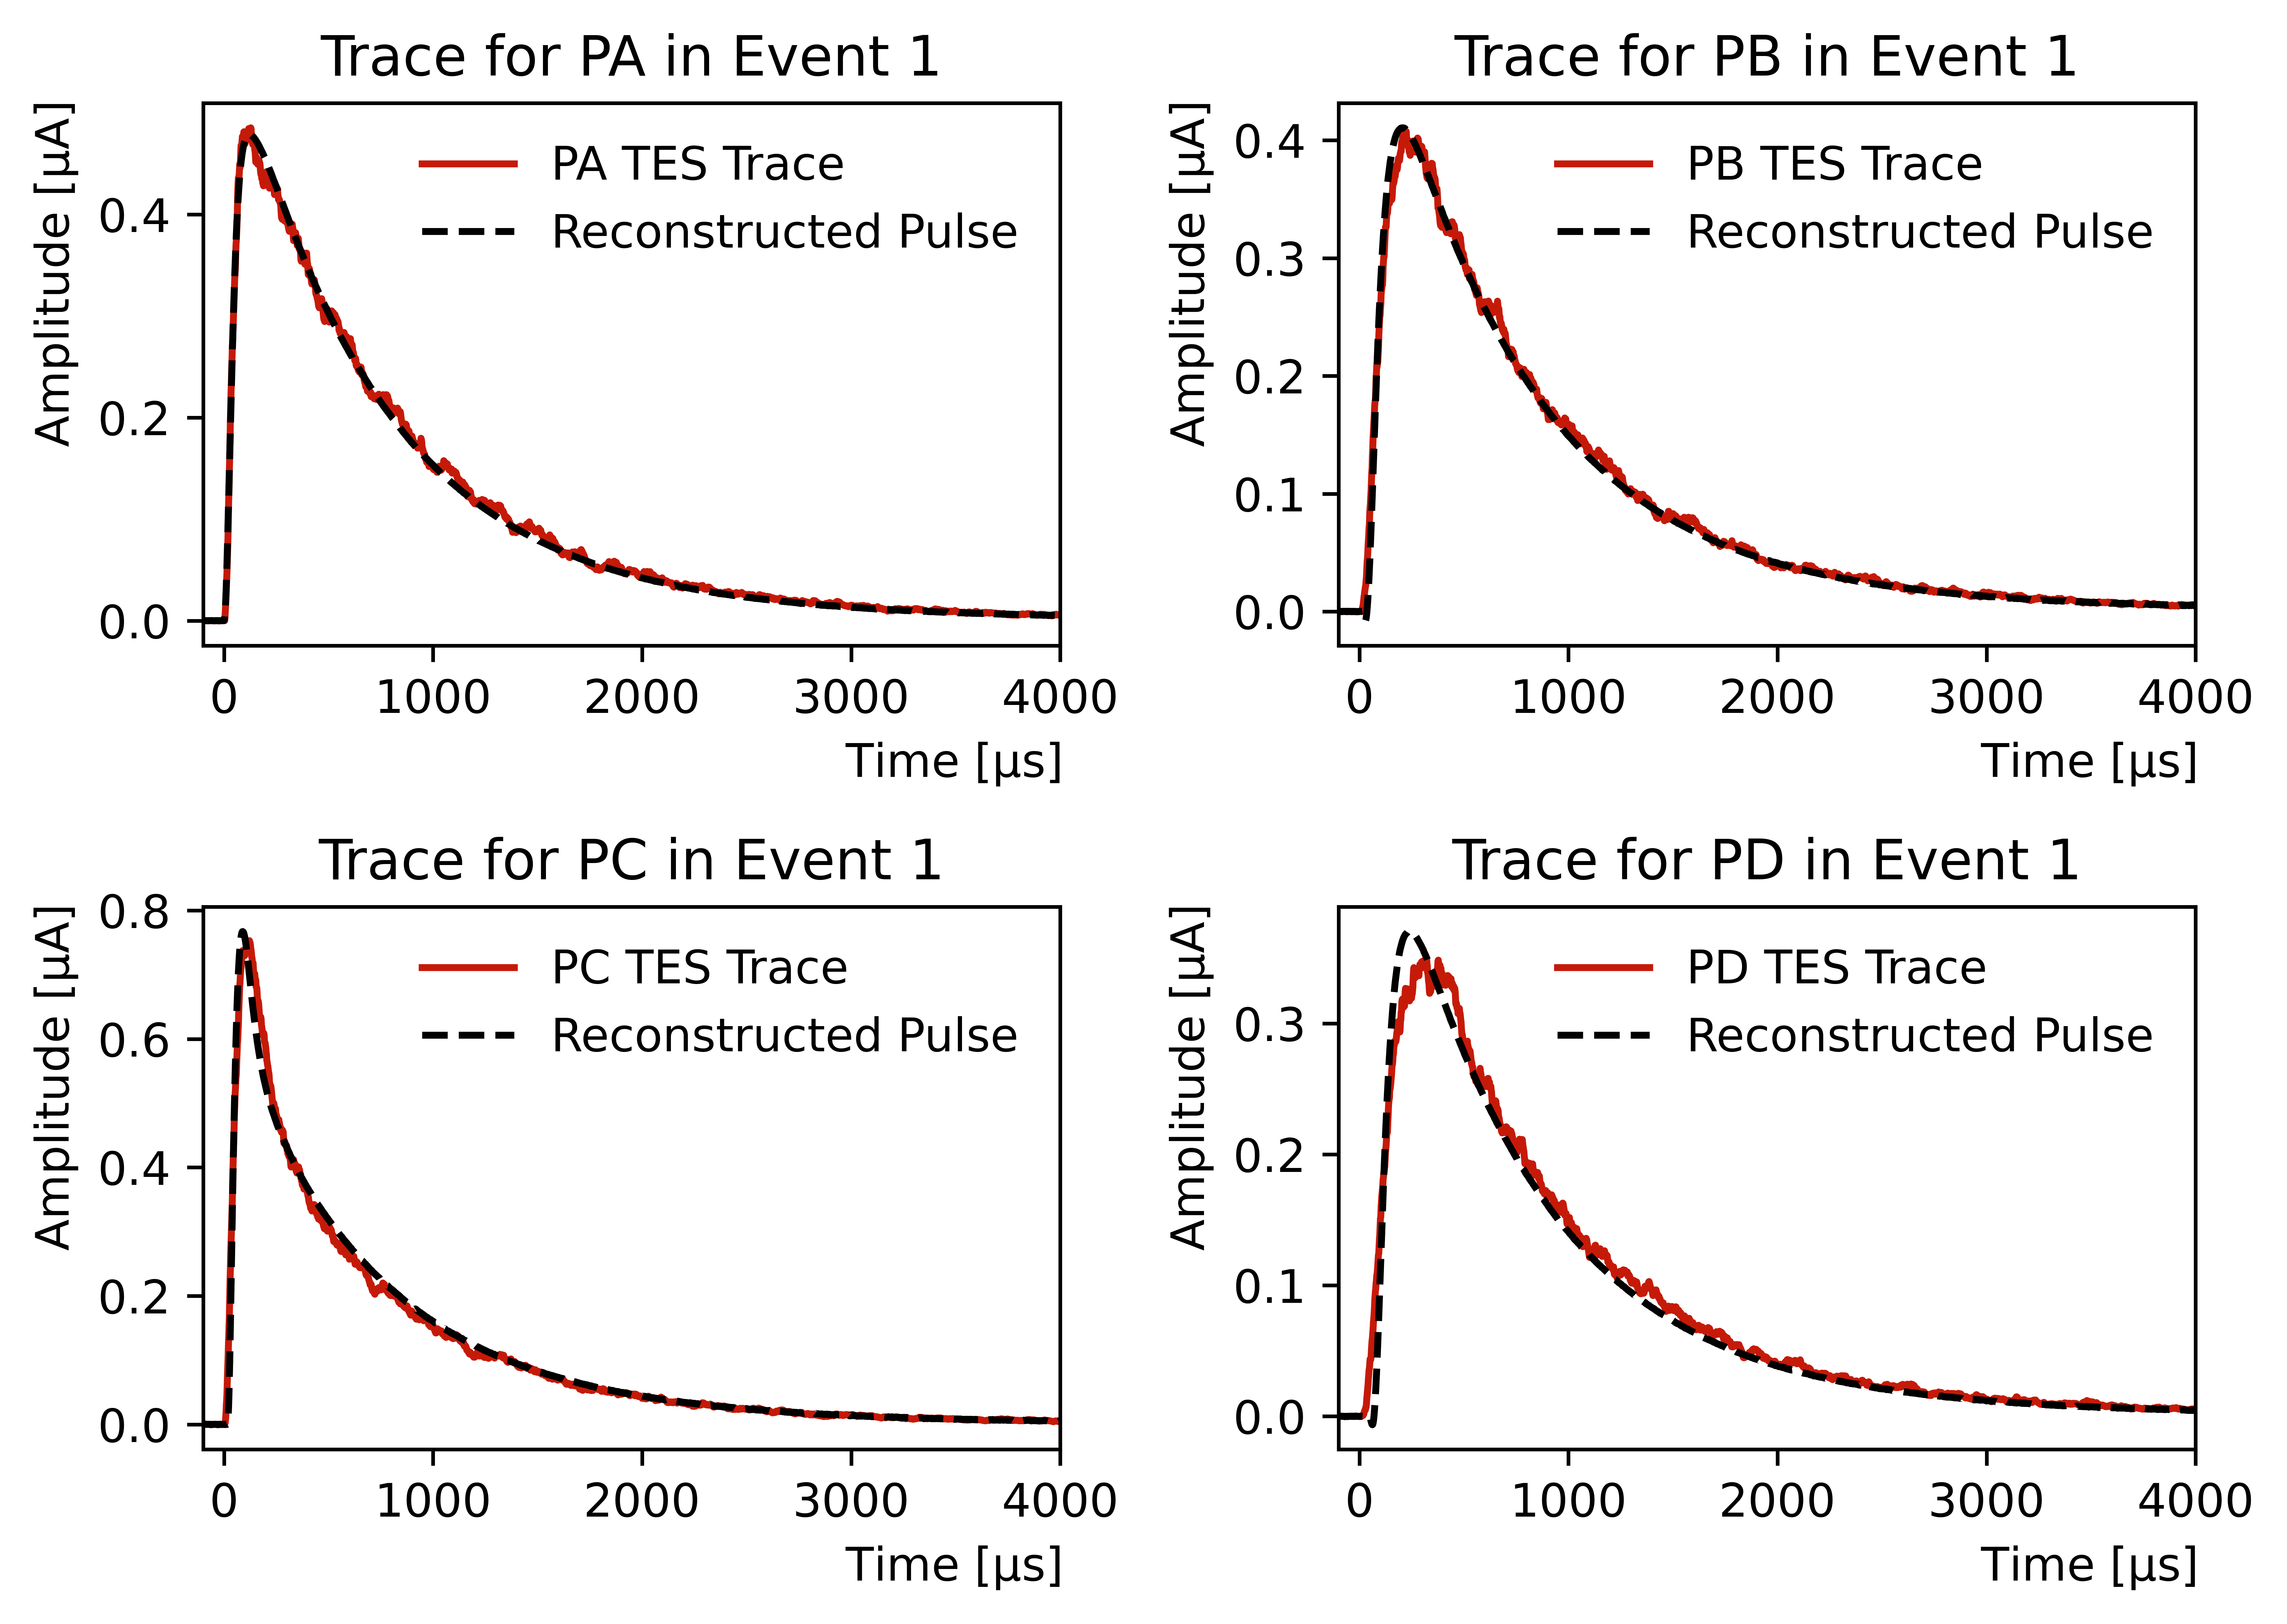

In [19]:
fig1, axes = plt.subplots(2,2,figsize=(7,5), dpi = 1000)
fig1.set_tight_layout(True)

for plot in range(4):
    currentAxis = axes.flatten()[plot]
    
    V = fft(Trace[plot]) # fourier transform of trace
    res = minimize(chisquare, [1, 1, 1])
    Ramp_fit, Pamp_fit, t_delay_fit = res.x
    
    currentAxis.plot(timeBins, Trace[plot], label=f'{ChanName[plot]} TES Trace', color = '#C61A09')
    currentAxis.plot(timeBins + t_delay_fit, Ramp_fit * fastTemplate + Pamp_fit * slowTemplate, ls = '--', color = 'black', label='Reconstructed Pulse')
    
    currentAxis.set_xlabel(r"Time [$\mathrm{\mu s}$]")
    currentAxis.set_ylabel(r"Amplitude [$\mathrm{\mu A}$]")
    currentAxis.set_title('Trace for ' + ChanName[plot] + ' in Event ' + str(EventNum))
    currentAxis.set_xlim(-100, 4000)
    currentAxis.legend(fontsize=6)

plt.tight_layout()